In [7]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [8]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

image_size = 64
latent_dim = 128
batch_size = 64
epochs = 50

lr = 0.0002
beta1 = 0.0
beta2 = 0.99

Using device: mps


In [10]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = torchvision.datasets.ImageFolder(
    root="../testCreateDataSet/pokemonResize",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

In [11]:
class MappingNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim,256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.ReLU(),
            nn.Linear(256,256)
        )

    def forward(self,x):
        return self.net(x)

In [12]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.ConvTranspose2d(256,512,4,1,0),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(512,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,w):

        w = w.view(-1,256,1,1)

        return self.net(w)

In [13]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,512,4,2,1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x).view(-1)

In [14]:
G = Generator().to(device)
D = Discriminator().to(device)
M = MappingNetwork().to(device)

criterion = nn.BCELoss()

opt_G = torch.optim.Adam(
    list(G.parameters()) + list(M.parameters()),
    lr=lr,
    betas=(beta1,beta2)
)

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(beta1,beta2)
)

In [15]:
for epoch in range(epochs):

    for real,_ in tqdm(loader):

        real = real.to(device)
        b = real.size(0)

        real_label = torch.ones(b).to(device)
        fake_label = torch.zeros(b).to(device)

        # Train Discriminator

        opt_D.zero_grad()

        out_real = D(real)
        loss_real = criterion(out_real,real_label)

        z = torch.randn(b,latent_dim).to(device)
        w = M(z)

        fake = G(w)

        out_fake = D(fake.detach())
        loss_fake = criterion(out_fake,fake_label)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # Train Generator

        opt_G.zero_grad()

        out = D(fake)

        loss_G = criterion(out,real_label)
        loss_G.backward()

        opt_G.step()

    print(epoch,loss_D.item(),loss_G.item())

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:20<00:00,  1.10s/it]


0 0.021140536293387413 7.404721736907959


100%|██████████| 19/19 [00:20<00:00,  1.06s/it]


1 0.08243577182292938 8.20490550994873


...

47 1.3024399280548096 0.8612496256828308


100%|██████████| 19/19 [00:20<00:00,  1.08s/it]


48 1.834986686706543 3.1367313861846924


100%|██████████| 19/19 [00:20<00:00,  1.08s/it]

49 1.3058100938796997 2.504450559616089


(np.float64(-0.5), np.float64(529.5), np.float64(529.5), np.float64(-0.5))

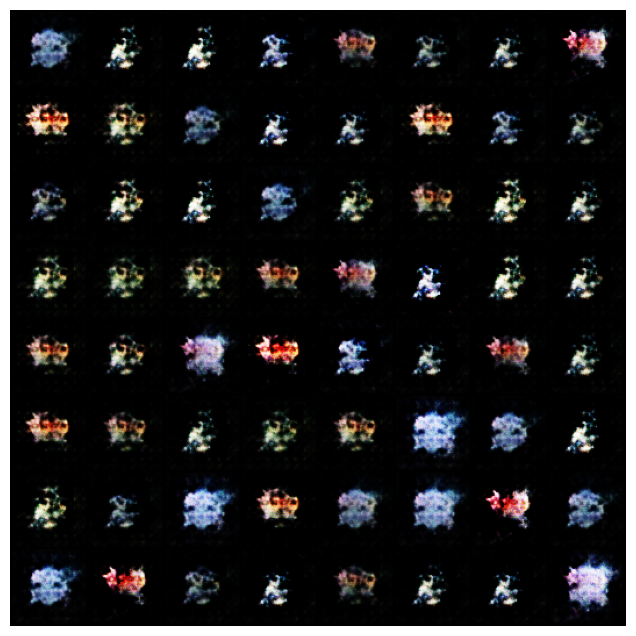

In [16]:
z = torch.randn(64,latent_dim).to(device)

w = M(z)

fake = G(w).detach().cpu()

grid = torchvision.utils.make_grid(fake,normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")